In [1]:
# Instalar dependencias se necessario
# !pip install networkx scipy matplotlib pandas


## Imports e carregamento dos dados

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from collections import defaultdict



In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/MO412_Project_v2/soc-sign-bitcoinotc.csv')
df.columns = ["source", "target", "rating", "time"]
df["time"] = pd.to_datetime(df["time"], unit="s")
df = df.sort_values("time").reset_index(drop=True)

G = nx.from_pandas_edgelist(
    df, source="source", target="target",
    edge_attr=["rating", "time"], create_using=nx.DiGraph()
)

print(f"Nodes: {G.number_of_nodes()} | Links: {G.number_of_edges()}")
print(f"Ratings: min={df.rating.min()} max={df.rating.max()}")
print(f"Period: {df.time.min().date()} --> {df.time.max().date()}")

Nodes: 5881 | Links: 35592
Ratings: min=-10 max=10
Period: 2010-11-08 --> 2016-01-25


## Reciprocity by signal

In [5]:
def sign(r):
    return "positive" if r > 0 else "negative"

edge_info = {}
for _, row in df.iterrows():
    u, v = row["source"], row["target"]
    if (u, v) not in edge_info:
        edge_info[(u, v)] = (sign(row["rating"]), row["time"])

reciprocated_pos = not_reciprocated_pos = 0
reciprocated_neg = not_reciprocated_neg = 0

for (u, v), (s, t_uv) in edge_info.items():
    has_reverse = (v, u) in edge_info
    if s == "positive":
        if has_reverse: reciprocated_pos += 1
        else:           not_reciprocated_pos += 1
    else:
        if has_reverse: reciprocated_neg += 1
        else:           not_reciprocated_neg += 1

total_pos = reciprocated_pos + not_reciprocated_pos
total_neg = reciprocated_neg + not_reciprocated_neg
p_rec_pos = reciprocated_pos / total_pos
p_rec_neg = reciprocated_neg / total_neg

print(f"Positive Links: {total_pos}")
print(f"  Reciprocated: {reciprocated_pos}  --> P(reciprocity | positive) = {p_rec_pos:.4f}")
print(f"Negative Links: {total_neg}")
print(f"  Reciprocated: {reciprocated_neg}  --> P(reciprocity | negative) = {p_rec_neg:.4f}")


contingency = [[reciprocated_pos, not_reciprocated_pos],
               [reciprocated_neg, not_reciprocated_neg]]
chi2, p_value, dof, _ = stats.chi2_contingency(contingency)
print(f"\nQui-square: chi2={chi2:.4f}, p={p_value:.4e}, gl={dof}")
if p_value < 0.05:
    print("Significative Diference (alfa=0.05).")
else:
    print("Non-significative Diference (alfa=0.05).")

Positive Links: 32029
  Reciprocated: 27234  --> P(reciprocity | positive) = 0.8503
Negative Links: 3563
  Reciprocated: 966  --> P(reciprocity | negative) = 0.2711

Qui-square: chi2=6532.5368, p=0.0000e+00, gl=1
Significative Diference (alfa=0.05).


## Temporal Analisys and reciprocity signal

In [12]:
delay_pospos, delay_negneg, delay_posneg, delay_negpos = [], [], [], []
visited_pairs = set()

for (u, v), (s_uv, t_uv) in edge_info.items():
    if (v, u) not in edge_info:
        continue
    pair = frozenset([u, v])
    if pair in visited_pairs:
        continue
    visited_pairs.add(pair)

    s_vu, t_vu = edge_info[(v, u)]

    if t_uv <= t_vu:
        t_first, t_second = t_uv, t_vu
        s_first, s_second = s_uv, s_vu
    else:
        t_first, t_second = t_vu, t_uv
        s_first, s_second = s_vu, s_uv

    delay_hours = (t_second - t_first).total_seconds() / 3600

    if s_first == "positive" and s_second == "positive":
        delay_pospos.append(delay_hours)
    elif s_first == "negative" and s_second == "negative":
        delay_negneg.append(delay_hours)
    elif s_first == "positive" and s_second == "negative":
        delay_posneg.append(delay_hours)
    elif s_first == "negative" and s_second == "positive":
        delay_negpos.append(delay_hours)

delay_pospos = np.array(delay_pospos)
delay_negneg = np.array(delay_negneg)
delay_posneg = np.array(delay_posneg)
delay_negpos = np.array(delay_negpos)

for label, arr in [("pos-pos", delay_pospos), ("neg-neg", delay_negneg),
                   ("pos->neg", delay_posneg), ("neg->pos", delay_negpos)]:
    print(f"\n  Reciprocated pairs {label}: {len(arr)}")
    if len(arr) > 0:
        print(f"    Median: {np.median(arr):.1f} hours")
        print(f"    Mean:   {np.mean(arr):.1f} hours")

stat_kw, p_kw = stats.kruskal(delay_pospos, delay_negneg, delay_posneg, delay_negpos)
print(f"\n  Kruskal-Wallis (4 groups): stat={stat_kw:.2f}, p={p_kw:.4e}")
if p_kw < 0.05:
    print("  -> Statistically significant difference among the four pair types.")

sign_given_pos_given_pos = 0   # A→B pos, B→A pos
sign_given_pos_given_neg = 0   # A→B pos, B→A neg
sign_given_neg_given_pos = 0   # A→B neg, B→A pos
sign_given_neg_given_neg = 0   # A→B neg, B→A neg

for (u, v), (s_uv, _) in edge_info.items():
    if (v, u) in edge_info:
        s_vu = edge_info[(v, u)][0]
        if s_uv == "positive":
            if s_vu == "positive": sign_given_pos_given_pos += 1
            else:                  sign_given_pos_given_neg += 1
        else:
            if s_vu == "positive": sign_given_neg_given_pos += 1
            else:                  sign_given_neg_given_neg += 1

tot_rec_pos = sign_given_pos_given_pos + sign_given_pos_given_neg
tot_rec_neg = sign_given_neg_given_pos + sign_given_neg_given_neg

print(f"\n  Reciprocal edge sign B→A:")
print(f"    Given A→B positive: "
      f"B→A positive={sign_given_pos_given_pos/tot_rec_pos:.3f}, "
      f"B→A negative={sign_given_pos_given_neg/tot_rec_pos:.3f}")
print(f"    Given A→B negative: "
      f"B→A positive={sign_given_neg_given_pos/tot_rec_neg:.3f}, "
      f"B→A positive={sign_given_neg_given_neg/tot_rec_neg:.3f}")


  Reciprocated pairs pos-pos: 13438
    Median: 0.1 hours
    Mean:   365.7 hours

  Reciprocated pairs neg-neg: 304
    Median: 7.4 hours
    Mean:   823.0 hours

  Reciprocated pairs pos->neg: 341
    Median: 741.5 hours
    Mean:   2845.6 hours

  Reciprocated pairs neg->pos: 17
    Median: 423.0 hours
    Mean:   3155.2 hours

  Kruskal-Wallis (4 groups): stat=852.75, p=1.5708e-184
  -> Statistically significant difference among the four pair types.

  Reciprocal edge sign B→A:
    Given A→B positive: B→A positive=0.987, B→A negative=0.013
    Given A→B negative: B→A positive=0.371, B→A positive=0.629


## PageRank and trust nodes

In [11]:
G_pos = nx.DiGraph()
for (u, v), (s, t) in edge_info.items():
    if s == "positive":
        G_pos.add_edge(u, v)

pagerank = nx.pagerank(G_pos, alpha=0.85)
pr_series = pd.Series(pagerank).sort_values(ascending=False)

threshold = pr_series.quantile(0.99)
highly_trusted = set(pr_series[pr_series >= threshold].index)
print(f"Highly trusted nodes (top 1%): {len(highly_trusted)}")
print(f"PageRank min in this group: {threshold:.6f}")

trusted_neg_edges = [(u, v) for (u, v), (s, _) in edge_info.items()
                     if s == "negative" and u in highly_trusted]
trusted_neg_targets = set(v for _, v in trusted_neg_edges)
print(f"Negative links of trusted nodes: {len(trusted_neg_edges)}")
print(f"Different targets: {len(trusted_neg_targets)}")

# Quantos dos 730 alvos também são nós confiáveis?
sobreposicao = trusted_neg_targets & highly_trusted
print(len(sobreposicao))

# Quantos nós confiáveis ficaram fora do G_neg?
fora_do_neg = highly_trusted - set(G_neg.nodes())
print(len(fora_do_neg))

Highly trusted nodes (top 1%): 56
PageRank min in this group: 0.001750
Negative links of trusted nodes: 1154
Different targets: 730
16
5


## BFS of negative spread

In [9]:
G_neg = nx.DiGraph()
for (u, v), (s, _) in edge_info.items():
    if s == "negative":
        G_neg.add_edge(u, v)

# BFS
distance_from_trusted = {}
visited = set()
trusted_in_neg = [n for n in highly_trusted if n in G_neg]
for node in trusted_in_neg:
    distance_from_trusted[node] = 0
    visited.add(node)

current_layer = list(trusted_in_neg)
for dist in range(1, 4):
    next_layer = []
    for node in current_layer:
        for neighbor in G_neg.successors(node):
            if neighbor not in visited:
                visited.add(neighbor)
                distance_from_trusted[neighbor] = dist
                next_layer.append(neighbor)
    current_layer = next_layer
    print(f"Nodes achieved in {dist} degree(s): {len(next_layer)}")

print(f"Nodes on negative graph NOT achieved: {G_neg.number_of_nodes() - len(distance_from_trusted)}")

# Negative out-degrees: targets vs others
out_neg_targets = [G_neg.out_degree(v) for v in trusted_neg_targets if v in G_neg]
out_neg_others  = [G_neg.out_degree(v) for v in G_neg.nodes()
                   if v not in trusted_neg_targets and v not in highly_trusted]
print(f"\nMean out-degree for negative graph:")
print(f"  Target of trusted nodes: {np.mean(out_neg_targets):.3f}")
print(f"  Other nodes:              {np.mean(out_neg_others):.3f}")
stat, p = stats.mannwhitneyu(out_neg_targets, out_neg_others, alternative="two-sided")
print(f"Mann-Whitney U p={p:.4e}")

Nodes achieved in 1 degree(s): 714
Nodes achieved in 2 degree(s): 198
Nodes achieved in 3 degree(s): 90
Nodes on negative graph NOT achieved: 553

Mean out-degree for negative graph:
  Target of trusted nodes: 2.341
  Other nodes:              1.502
Mann-Whitney U p=6.6951e-15


## Plots

/tmp/ipykernel_485/3867768451.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


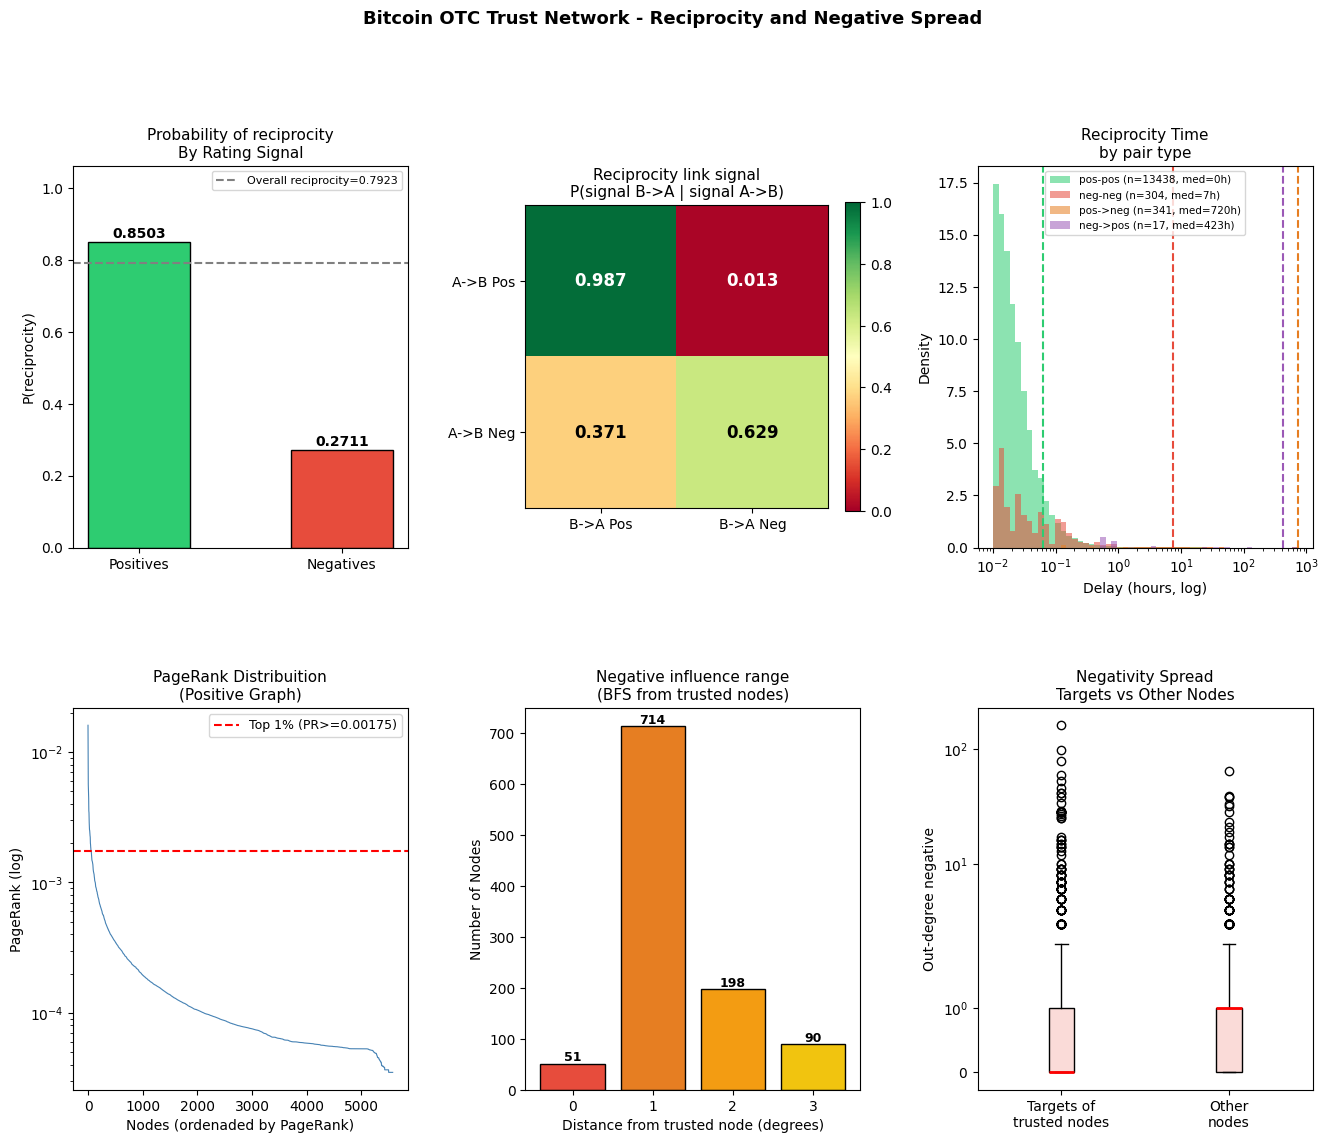

In [13]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)


ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(["Positives", "Negatives"], [p_rec_pos, p_rec_neg],
               color=["#2ecc71", "#e74c3c"], edgecolor="black", width=0.5)
for bar, val in zip(bars, [p_rec_pos, p_rec_neg]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.set_ylim(0, max(p_rec_pos, p_rec_neg) * 1.25)
ax1.set_ylabel("P(reciprocity)")
ax1.set_title("Probability of reciprocity\nBy Rating Signal", fontsize=11)
reciprocity_val = nx.reciprocity(G)
ax1.axhline(reciprocity_val, ls="--", color="gray",
            label=f"Overall reciprocity={reciprocity_val:.4f}")
ax1.legend(fontsize=8)


ax2 = fig.add_subplot(gs[0, 1])
matrix = np.array([[sgpp/trp, sgpn/trp], [sgnp/trn, sgnn/trn]])
im = ax2.imshow(matrix, cmap="RdYlGn", vmin=0, vmax=1)
ax2.set_xticks([0, 1]); ax2.set_xticklabels(["B->A Pos", "B->A Neg"])
ax2.set_yticks([0, 1]); ax2.set_yticklabels(["A->B Pos", "A->B Neg"])
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f"{matrix[i,j]:.3f}", ha="center", va="center",
                 fontsize=12, fontweight="bold",
                 color="white" if matrix[i,j] < 0.3 or matrix[i,j] > 0.7 else "black")
ax2.set_title("Reciprocity link signal\nP(signal B->A | signal A->B)", fontsize=11)
plt.colorbar(im, ax=ax2, fraction=0.046)


ax3 = fig.add_subplot(gs[0, 2])
clip = 24 * 30
bins = np.logspace(np.log10(0.01), np.log10(clip), 55)

groups = [
    (delay_pospos, "#2ecc71", "pos-pos"),
    (delay_negneg, "#e74c3c", "neg-neg"),
    (delay_posneg, "#e67e22", "pos->neg"),
    (delay_negpos, "#9b59b6", "neg->pos"),
]
for arr, color, label in groups:
    d = np.clip(arr[arr > 0], 0, clip)
    if len(d) == 0:
        continue
    med = np.median(d)
    ax3.hist(d, bins=bins, alpha=0.55, color=color,
             label=f"{label} (n={len(arr)}, med={med:.0f}h)", density=True)
    ax3.axvline(med, color=color, lw=1.5, ls="--")

ax3.set_xscale("log")
ax3.set_xlabel("Delay (hours, log)")
ax3.set_ylabel("Density")
ax3.set_title("Reciprocity Time\nby pair type", fontsize=11)
ax3.legend(fontsize=7.5)


ax4 = fig.add_subplot(gs[1, 0])
pr_vals = pr_series.values
ax4.plot(np.arange(len(pr_vals)), pr_vals, color="steelblue", lw=0.8)
ax4.axhline(threshold, color="red", ls="--", label=f"Top 1% (PR>={threshold:.5f})")
ax4.set_yscale("log")
ax4.set_xlabel("Nodes (ordenaded by PageRank)")
ax4.set_ylabel("PageRank (log)")
ax4.set_title("PageRank Distribuition\n(Positive Graph)", fontsize=11)
ax4.legend(fontsize=9)


ax5 = fig.add_subplot(gs[1, 1])
dist_counts = pd.Series(distance_from_trusted).value_counts().sort_index()
dist_counts = dist_counts[dist_counts.index <= 3]
ax5.bar(dist_counts.index.astype(str), dist_counts.values,
        color=["#e74c3c", "#e67e22", "#f39c12", "#f1c40f"],
        edgecolor="black")
ax5.set_xlabel("Distance from trusted node (degrees)")
ax5.set_ylabel("Number of Nodes")
ax5.set_title("Negative influence range\n(BFS from trusted nodes)", fontsize=11)
for i, (x, y) in enumerate(zip(dist_counts.index.astype(str), dist_counts.values)):
    ax5.text(i, y + 5, str(y), ha="center", fontsize=9, fontweight="bold")

# Plot 6: Boxplot grau negativo
ax6 = fig.add_subplot(gs[1, 2])
ax6.boxplot([out_neg_targets, out_neg_others],
            tick_labels=["Targets of\ntrusted nodes", "Other\nnodes"],
            patch_artist=True,
            boxprops=dict(facecolor="#fadbd8"),
            medianprops=dict(color="red", lw=2))
ax6.set_ylabel("Out-degree negative")
ax6.set_title("Negativity Spread\nTargets vs Other Nodes", fontsize=11)
ax6.set_yscale("symlog")

fig.suptitle("Bitcoin OTC Trust Network - Reciprocity and Negative Spread",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()